In [2]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# Paths to the train and test directories
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to extract paths and labels
def get_paths_and_labels(directory):
    paths = []
    labels = []
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if os.path.isdir(folder_path):  # Check if it's a directory
            label = labels_dict.get(folder, 'Unknown')  # Get label based on folder name
            for filename in os.listdir(folder_path):
                file_path = os.path.join(folder_path, filename)
                paths.append(file_path)
                labels.append(label)
    return paths, labels

# Get train paths and labels
train_paths, train_labels = get_paths_and_labels(train_dir)

# Get test paths and labels
test_paths, test_labels = get_paths_and_labels(test_dir)

# Combine train and test data
all_paths = train_paths + test_paths
all_labels = train_labels + test_labels

# Create a DataFrame
df = pd.DataFrame({
    'path': all_paths,
    'label': all_labels
})

# Load only the TRAIN data for splitting into train/val
train_paths, train_labels = get_paths_and_labels(train_dir)

# Create DataFrame for training data only
train_df = pd.DataFrame({
    'path': train_paths,
    'label': train_labels
})

print("Full training data distribution:")
print(train_df['label'].value_counts())

# Split into train and validation (stratified)
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print("\nAfter split - Training set:")
print(train_df_split['label'].value_counts())
print("\nValidation set:")
print(val_df['label'].value_counts())

# Create separate test DataFrame (no augmentation, untouched)
test_paths, test_labels = get_paths_and_labels(test_dir)
test_df = pd.DataFrame({
    'path': test_paths,
    'label': test_labels
})

print("\nTest set (hold-out) distribution:")
print(test_df['label'].value_counts())


Full training data distribution:
label
Normal                               75709
Murmur                                8405
Premature Ventricular Contraction     6431
Ventricular Tachycardia               5789
Supraventricular Tachycardia          2223
Atrial Fibrillation                    642
Name: count, dtype: int64

After split - Training set:
label
Normal                               60567
Murmur                                6724
Premature Ventricular Contraction     5145
Ventricular Tachycardia               4631
Supraventricular Tachycardia          1778
Atrial Fibrillation                    514
Name: count, dtype: int64

Validation set:
label
Normal                               15142
Murmur                                1681
Premature Ventricular Contraction     1286
Ventricular Tachycardia               1158
Supraventricular Tachycardia           445
Atrial Fibrillation                    128
Name: count, dtype: int64

Test set (hold-out) distribution:
label
Normal    

In [3]:
df

,path,label
0,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
1,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
2,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
3,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
4,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
...,...,...
123993,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123994,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123995,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123996,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia


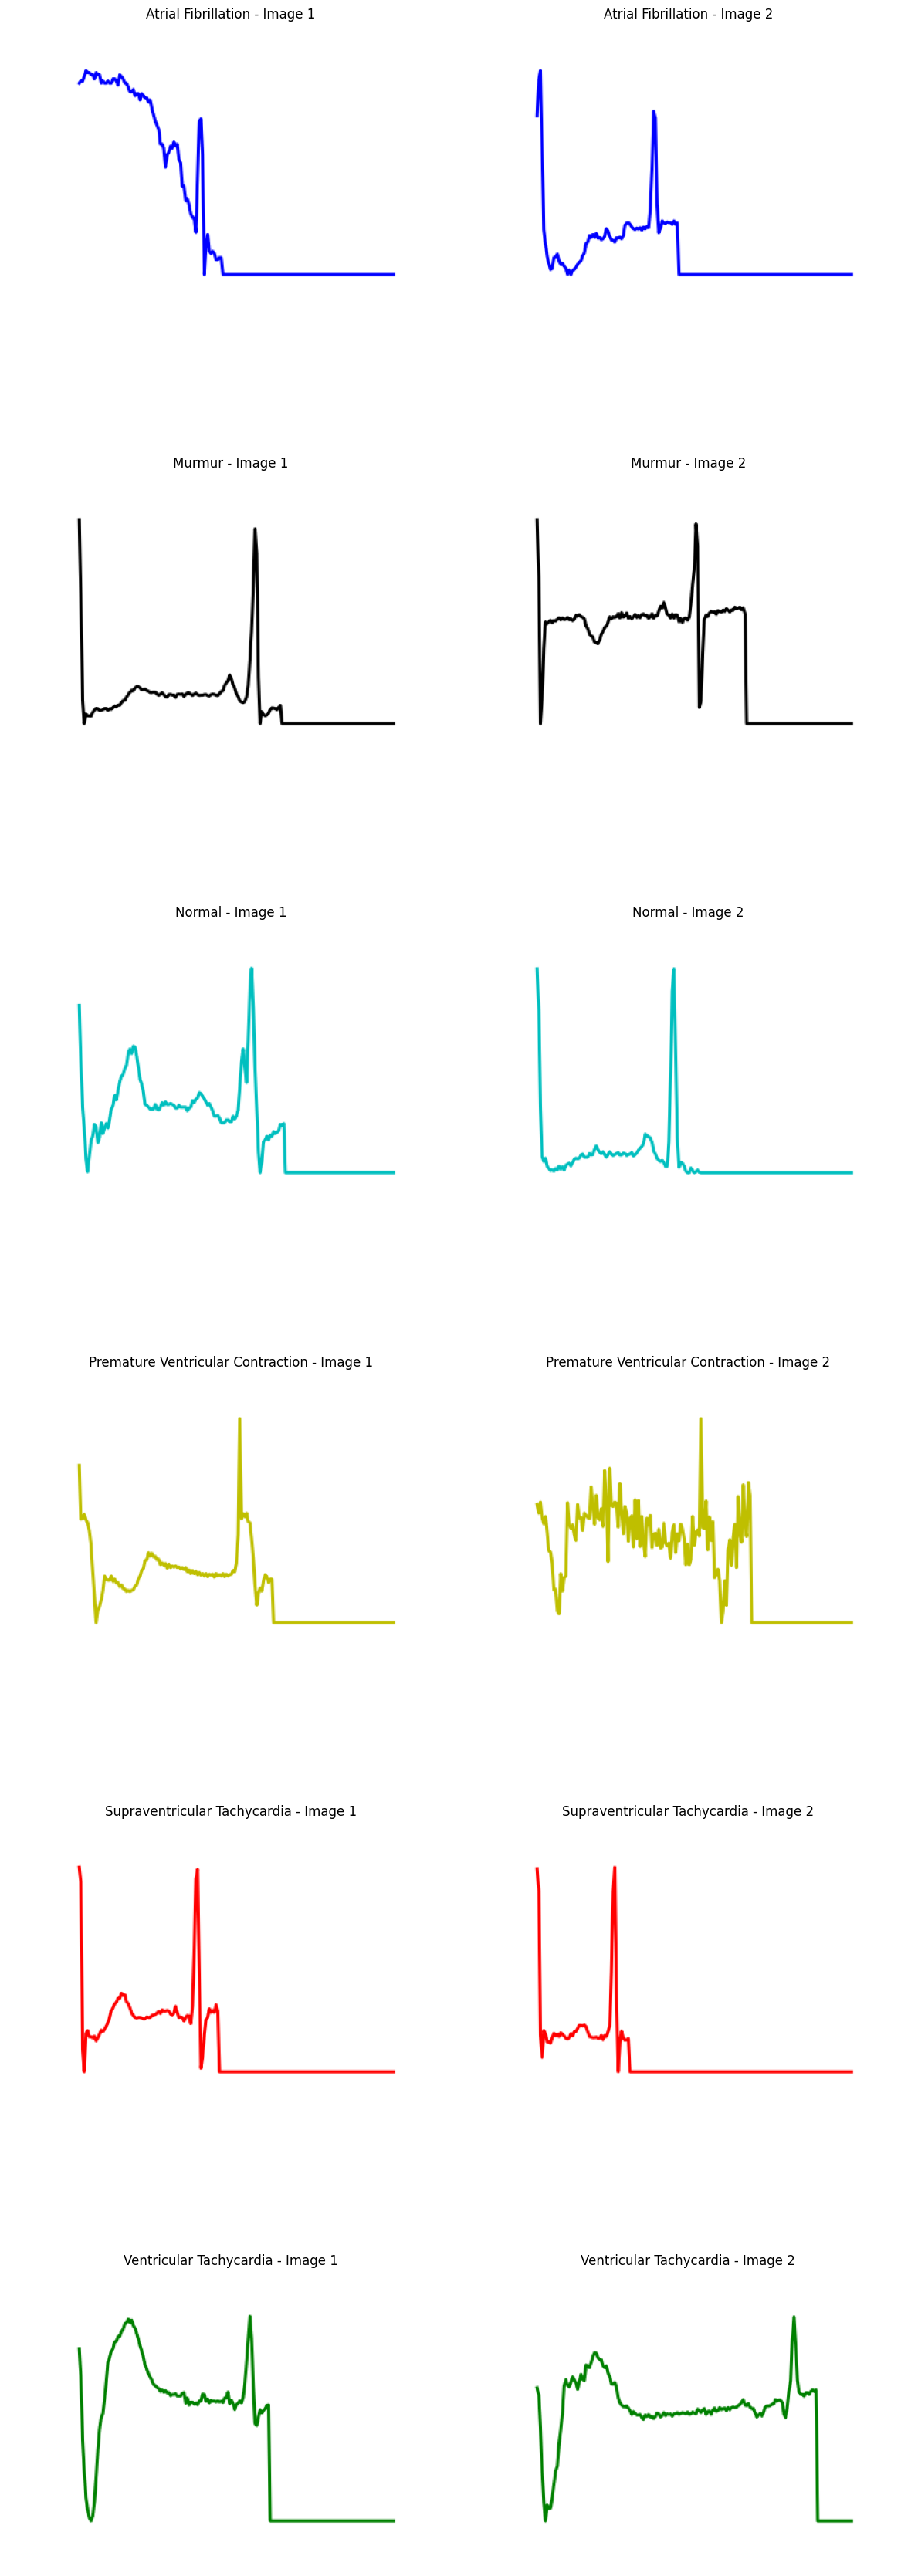

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to load images for each class
def load_images_for_class(class_name, num_images=2):
    class_folder = os.path.join(train_dir, class_name)
    images = []
    for filename in os.listdir(class_folder)[:num_images]:
        image_path = os.path.join(class_folder, filename)
        images.append(image_path)
    return images

# Calculate the number of rows based on the number of classes
num_classes = len(labels_dict)
num_images_per_class = 2  # Number of images per class
rows = num_classes  # Each class will take one row with two images

# Set up the plot size dynamically based on the number of rows and images per row
fig, axes = plt.subplots(rows, num_images_per_class, figsize=(12, rows*6))
axes = axes.ravel()  # Flatten the axes to make it easier to index

# Loop through each class and display two images side by side
for idx, (class_key, class_label) in enumerate(labels_dict.items()):
    images = load_images_for_class(class_key, num_images=num_images_per_class)
    
    for i, image_path in enumerate(images):
        img = mpimg.imread(image_path)
        ax = axes[idx * num_images_per_class + i]  # Select the correct subplot
        ax.imshow(img)
        ax.set_title(f"{class_label} - Image {i+1}")
        ax.axis('off')  # Hide axis

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


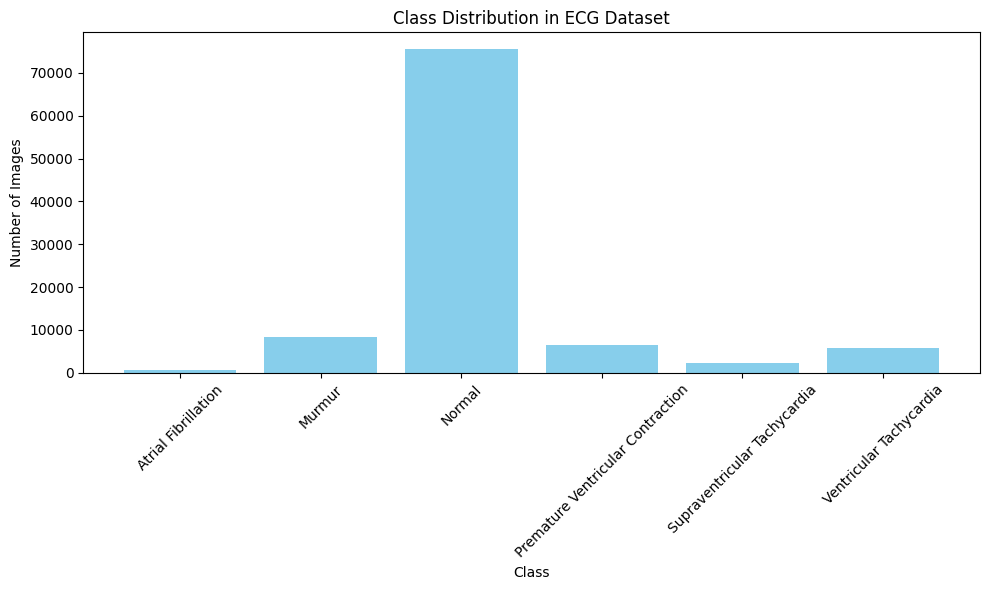

In [5]:
# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to count images for each class
def count_images_for_classes(directory):
    class_counts = {label: 0 for label in labels_dict.values()}
    for folder in os.listdir(directory):
        if folder in labels_dict:
            class_label = labels_dict[folder]
            class_folder = os.path.join(directory, folder)
            num_images = len(os.listdir(class_folder))
            class_counts[class_label] += num_images
    return class_counts

# Get the class distribution
class_distribution = count_images_for_classes(train_dir)

# Create a DataFrame for visualization
df_class_distribution = pd.DataFrame(list(class_distribution.items()), columns=['Class', 'Count'])

# Plot the class distribution
plt.figure(figsize=(10, 6))
plt.bar(df_class_distribution['Class'], df_class_distribution['Count'], color='skyblue')
plt.title('Class Distribution in ECG Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
df['label'].value_counts()

label
Normal                               94635
Murmur                               10506
Premature Ventricular Contraction     8039
Ventricular Tachycardia               7236
Supraventricular Tachycardia          2779
Atrial Fibrillation                    803
Name: count, dtype: int64

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from shutil import copyfile

# New output directory for the small dataset
small_train_dir = '/kaggle/working/small_balanced_train'
os.makedirs(small_train_dir, exist_ok=True)

# Create class subfolders
labels = list(labels_dict.values())
for label in labels:
    os.makedirs(os.path.join(small_train_dir, label), exist_ok=True)

# Target: 600 images per class
target_per_class = 600

# Load original training data
train_paths, train_labels = get_paths_and_labels(train_dir)
train_df = pd.DataFrame({'path': train_paths, 'label': train_labels})

# Group by class
grouped = train_df.groupby('label')

print("Starting creation of small balanced dataset (600 images per class)...")

for label, group in grouped:
    label_folder = os.path.join(small_train_dir, label)
    current_images = group['path'].tolist()
    num_current = len(current_images)
    
    print(f"\nProcessing class: {label} ({num_current} original images) -> selecting {target_per_class}")
    
    # Randomly select 600 unique images
    selected_paths = np.random.choice(current_images, target_per_class, replace=False)
    
    for i, src_path in enumerate(tqdm(selected_paths, desc=f"Copying {label}")):
        # Read and copy (with optional light variation)
        image = cv2.imread(src_path)
        if image is None:
            continue  # Skip bad images
        
        # Optional: Apply mild random augmentation to 50% of images for variety
        if np.random.rand() > 0.5:
            # Simple random brightness/contrast or small rotate
            if np.random.rand() > 0.5:
                image = cv2.convertScaleAbs(image, alpha=np.random.uniform(0.8, 1.2), beta=np.random.randint(-20, 20))
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
            image = cv2.warpAffine(image, M, (w, h))
        
        # Save with unique name
        base_name = os.path.splitext(os.path.basename(src_path))[0]
        ext = os.path.splitext(src_path)[1]
        new_filename = f"{base_name}_small_{i}{ext}"
        dst_path = os.path.join(label_folder, new_filename)
        cv2.imwrite(dst_path, image)

print("\nSmall balanced dataset created at:", small_train_dir)

# Verify distribution
small_paths, small_labels = get_paths_and_labels(small_train_dir)
small_df = pd.DataFrame({'path': small_paths, 'label': small_labels})
print("\nFinal small balanced distribution:")
print(small_df['label'].value_counts())

Starting creation of small balanced dataset (600 images per class)...

Processing class: Atrial Fibrillation (642 original images) -> selecting 600


Copying Atrial Fibrillation: 100%|██████████| 600/600 [00:05<00:00, 116.35it/s]



Processing class: Murmur (8405 original images) -> selecting 600


Copying Murmur: 100%|██████████| 600/600 [00:05<00:00, 112.05it/s]



Processing class: Normal (75709 original images) -> selecting 600


...


Processing class: Supraventricular Tachycardia (2223 original images) -> selecting 600


Copying Supraventricular Tachycardia: 100%|██████████| 600/600 [00:05<00:00, 111.64it/s]



Processing class: Ventricular Tachycardia (5789 original images) -> selecting 600


Copying Ventricular Tachycardia: 100%|██████████| 600/600 [00:05<00:00, 110.68it/s]


Small balanced dataset created at: /kaggle/working/small_balanced_train

Final small balanced distribution:
label
Unknown    3600
Name: count, dtype: int64


In [8]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# === Paths ===
small_train_dir = '/kaggle/working/small_balanced_train'   # Your 600-per-class dataset
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# === Define ImageDataGenerators ===
# Training: with light augmentation + validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2  # 20% for validation
)

# Validation & Test: only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# === Create Generators from Small Balanced Dataset ===
train_generator = train_datagen.flow_from_directory(
    small_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='training',      # 80% → ~480 images per class (2880 total)
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    small_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',    # 20% → ~120 images per class (720 total)
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print("Class indices:", train_generator.class_indices)

# === Test Generator from Original Full Test Set (using DataFrame) ===
# Make sure test_df is already created from earlier code
# If not, run this:
test_paths, test_labels = get_paths_and_labels(test_dir)
test_df = pd.DataFrame({'path': test_paths, 'label': test_labels})

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(f"Test samples: {test_generator.samples}")
print("Test class indices:", test_generator.class_indices)

Found 2880 images belonging to 6 classes.
Found 720 images belonging to 6 classes.
Training samples: 2880
Validation samples: 720
Class indices: {'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}
Found 24799 validated image filenames belonging to 6 classes.
Test samples: 24799
Test class indices: {'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}


In [9]:
import os
import pandas as pd

# Function to count images per class in a directory
def get_class_counts_from_directory(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

print("=== CLASS DISTRIBUTION ===\n")

# 1. Training set (from train_generator)
train_counts = train_generator.classes
train_labels = list(train_generator.class_indices.keys())
train_value_counts = pd.Series(train_counts).value_counts().sort_index()
train_value_counts.index = [train_labels[i] for i in train_value_counts.index]

print("Training Set (80% of balanced data):")
print(train_value_counts)
print(f"Total training images: {len(train_generator.classes)}\n")

# 2. Validation set (from val_generator)
val_counts = val_generator.classes
val_value_counts = pd.Series(val_counts).value_counts().sort_index()
val_value_counts.index = [train_labels[i] for i in val_value_counts.index]

print("Validation Set (20% of balanced data):")
print(val_value_counts)
print(f"Total validation images: {len(val_generator.classes)}\n")



# Optional: Show class indices mapping
print("Class indices mapping:")
print(train_generator.class_indices)

=== CLASS DISTRIBUTION ===

Training Set (80% of balanced data):
Atrial Fibrillation                  480
Murmur                               480
Normal                               480
Premature Ventricular Contraction    480
Supraventricular Tachycardia         480
Ventricular Tachycardia              480
Name: count, dtype: int64
Total training images: 2880

Validation Set (20% of balanced data):
Atrial Fibrillation                  120
Murmur                               120
Normal                               120
Premature Ventricular Contraction    120
Supraventricular Tachycardia         120
Ventricular Tachycardia              120
Name: count, dtype: int64
Total validation images: 720

Class indices mapping:
{'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Paths
balanced_train_dir = '/kaggle/working/small_balanced_train'
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# === FIXED: Separate datagens without validation_split ===
# Training: with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation & Test: only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create base 2D generators (NO validation_split)
train_gen_2d = train_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# For validation: use same datagen but with validation_split alternative
# We'll use 20% of data for validation by calculating steps manually or using a trick
# Best way: use validation_split in a separate datagen for val only
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen_2d = val_datagen.flow_from_directory(
    balanced_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',   # This works if validation_split is supported in this call
    shuffle=False,
    seed=42
)

# If subset='validation' still fails, fall back to manual split (see note below)

# === Custom 3D wrapper generator with depth repetition ===
def custom_3d_generator(base_generator, repeat_channels=3):
    while True:
        x, y = next(base_generator)                  # (batch, 160, 160, 3)
        x_3d = np.repeat(x, repeat_channels, axis=-1)  # (batch, 160, 160, 9)
        x_3d = np.expand_dims(x_3d, axis=-1)           # (batch, 160, 160, 9, 1)
        yield x_3d, y

# Create 3D generators (now with augmentation in training)
train_generator = custom_3d_generator(train_gen_2d, repeat_channels=3)
val_generator = custom_3d_generator(val_gen_2d, repeat_channels=3)

class_indices = train_gen_2d.class_indices
print("Class indices:", class_indices)

# === Test generator using DataFrame (reliable) ===
test_paths, test_labels = get_paths_and_labels(test_dir)
test_df = pd.DataFrame({'path': test_paths, 'label': test_labels})

test_gen_2d = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='label',
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = custom_3d_generator(test_gen_2d, repeat_channels=3)

Found 3600 images belonging to 6 classes.
Found 720 images belonging to 6 classes.
Class indices: {'Atrial Fibrillation': 0, 'Murmur': 1, 'Normal': 2, 'Premature Ventricular Contraction': 3, 'Supraventricular Tachycardia': 4, 'Ventricular Tachycardia': 5}
Found 24799 validated image filenames belonging to 6 classes.


In [12]:
def create_3d_cnn_model(input_shape=(160, 160, 9, 1), num_classes=6):
    model = models.Sequential([
        # Block 1
        layers.Conv3D(32, (3, 3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 1)),  # Only pool H and W

        # Block 2
        layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 1)),

        # Block 3
        layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 1)),

        # Block 4
        layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling3D((2, 2, 1)),

        # Optional: one small depth reduction at the end if needed
        # layers.MaxPooling3D((1, 1, 3)),  # Reduce depth from 9 → 3 (optional)

        layers.GlobalAveragePooling3D(),  # Safely averages over all spatial dims

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Recreate the model with fixed pooling
model_3d = create_3d_cnn_model()
model_3d.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1768630471.000293      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 160, 160, 9,    │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 9,    │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 80, 80, 9, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 80, 80, 9, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 9, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 40, 40, 9, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 40, 40, 9, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 9, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 20, 20, 9, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 20, 20, 9, 256) │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 9, 256) │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 10, 10, 9, 256) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,428,934 (5.45 MB)

 Trainable params: 1,427,974 (5.45 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
# Steps calculation
train_steps = train_gen_2d.samples // 32
val_steps = val_gen_2d.samples // 32
test_steps = test_gen_2d.samples // 32 + 1

callbacks = [
    ModelCheckpoint('/kaggle/working/best_3d_cnn_fixed.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

# Train
history = model_3d.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_steps,
    callbacks=callbacks
)

model_3d.save('/kaggle/working/3d_cnn_final_fixed.h5')

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 1.0000 - loss: 5.9910e-05
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to /kaggle/working/best_3d_cnn_fixed.h5


112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 359ms/step - accuracy: 1.0000 - loss: 5.9936e-05 - val_accuracy: 1.0000 - val_loss: 1.0861e-04 - learning_rate: 5.0000e-04
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 1.0000 - loss: 5.5632e-05
Epoch 2: val_accuracy did not improve from 1.00000
112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 356ms/step - accuracy: 1.0000 - loss: 5.5599e-05 - val_accuracy: 1.0000 - val_loss: 7.7582e-05 - learning_rate: 5.0000e-04
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 1.0000 - loss: 2.4404e-04
Epoch 3: val_accuracy did not improve from 1.00000
112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 356ms/step - accuracy: 1.0000 - loss: 2.4378e-04 - val_accuracy: 1.0000 - val_loss: 3.1977e-04 - learning_rate: 5.0000e-04
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 1.0000 - loss: 2.4801e-05
Epoch 4: val_accuracy did not improve from 1.00000
112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 356ms/step - accuracy: 1.0000 - loss: 2.4891e-05 - val_accuracy: 1.000

775/775 ━━━━━━━━━━━━━━━━━━━━ 189s 242ms/step - accuracy: 1.0000 - loss: 1.1678e-07

Final Test Accuracy: 1.0000
Final Test Loss: 0.0000
775/775 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step


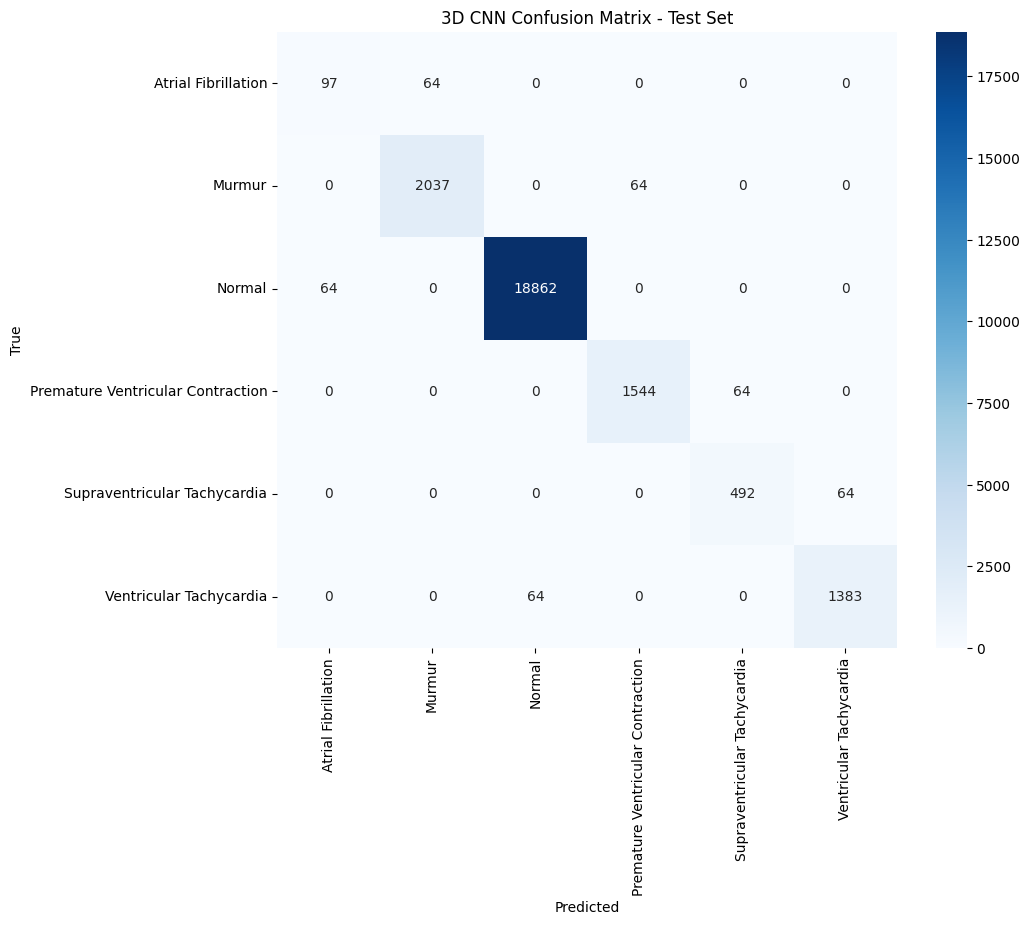

3D CNN Classification Report:
                                   precision    recall  f1-score   support

              Atrial Fibrillation       0.60      0.60      0.60       161
                           Murmur       0.97      0.97      0.97      2101
                           Normal       1.00      1.00      1.00     18926
Premature Ventricular Contraction       0.96      0.96      0.96      1608
     Supraventricular Tachycardia       0.88      0.88      0.88       556
          Ventricular Tachycardia       0.96      0.96      0.96      1447

                         accuracy                           0.98     24799
                        macro avg       0.89      0.89      0.89     24799
                     weighted avg       0.98      0.98      0.98     24799



In [15]:
# Load best model
best_model = models.load_model('/kaggle/working/best_3d_cnn_fixed.h5')

# Evaluate
test_loss, test_acc = best_model.evaluate(test_generator, steps=test_steps, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Predictions
y_pred = best_model.predict(test_generator, steps=test_steps)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen_2d.classes  # Use test_gen_2d for true labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_indices.keys(),
            yticklabels=class_indices.keys())
plt.title('3D CNN Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=list(class_indices.keys()))
print("3D CNN Classification Report:")
print(report)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 158, 158, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 77, 77, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,912,326 (34.00 MB)

 Trainable params: 8,911,366 (33.99 MB)

 Non-trainable params: 960 (3.75 KB)

...

113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.6686 - loss: 3.1164 - val_accuracy: 0.1667 - val_loss: 15.3747 - learning_rate: 0.0010
Epoch 2/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9778 - loss: 0.1704
Epoch 2: val_accuracy improved from 0.16667 to 0.19861, saving model to /kaggle/working/best_cnn_balanced_model.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 212ms/step - accuracy: 0.9778 - loss: 0.1705 - val_accuracy: 0.1986 - val_loss: 13.8076 - learning_rate: 0.0010
Epoch 3/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9776 - loss: 0.3715
Epoch 3: val_accuracy improved from 0.19861 to 0.65833, saving model to /kaggle/working/best_cnn_balanced_model.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - accuracy: 0.9776 - loss: 0.3716 - val_accuracy: 0.6583 - val_loss: 8.5812 - learning_rate: 0.0010
Epoch 4/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9975 - loss: 0.0425
Epoch 4: val_accuracy did not improve from 0.65833
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.9974 - loss: 0.0434 - val_accuracy: 0.2028 - val_loss: 44.6614 - learning_rate: 0.0010
Epoch 5/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9750 - loss: 0.6489
Epoch 5: val_accuracy improved from 0.65833 to 0.95139, saving model to /kaggle/working/best_cnn_balanced_model.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.9750 - loss: 0.6477 - val_accuracy: 0.9514 - val_loss: 2.1193 - learning_rate: 0.0010
Epoch 6/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9970 - loss: 0.0728
Epoch 6: val_accuracy did not improve from 0.95139
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - accuracy: 0.9970 - loss: 0.0728 - val_accuracy: 0.5889 - val_loss: 37.3757 - learning_rate: 0.0010
Epoch 7/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9981 - loss: 0.0286
Epoch 7: val_accuracy improved from 0.95139 to 1.00000, saving model to /kaggle/working/best_cnn_balanced_model.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 216ms/step - accuracy: 0.9981 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 9.4905e-07 - learning_rate: 0.0010
Epoch 8/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9982 - loss: 0.0158
Epoch 8: val_accuracy did not improve from 1.00000
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - accuracy: 0.9982 - loss: 0.0163 - val_accuracy: 0.8319 - val_loss: 4.6155 - learning_rate: 0.0010
Epoch 9/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9944 - loss: 0.1243
Epoch 9: val_accuracy did not improve from 1.00000
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - accuracy: 0.9944 - loss: 0.1246 - val_accuracy: 0.4847 - val_loss: 78.5723 - learning_rate: 0.0010
Epoch 10/17
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9883 - loss: 0.6248
Epoch 10: val_accuracy did not improve from 1.00000

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 209ms/step - accuracy: 0.9883 - l

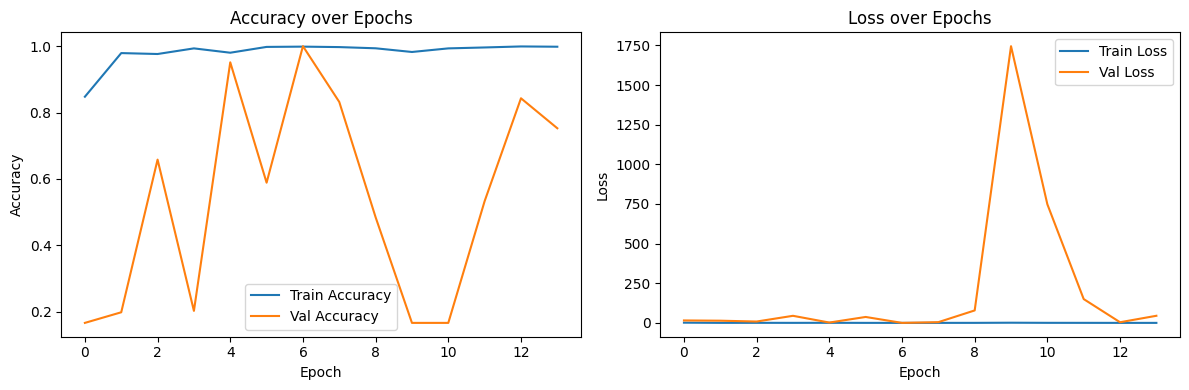

775/775 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 1.0000 - loss: 1.1532e-04

Final Test Accuracy (on original imbalanced test set): 0.9996
Final Test Loss: 0.0030
775/775 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step


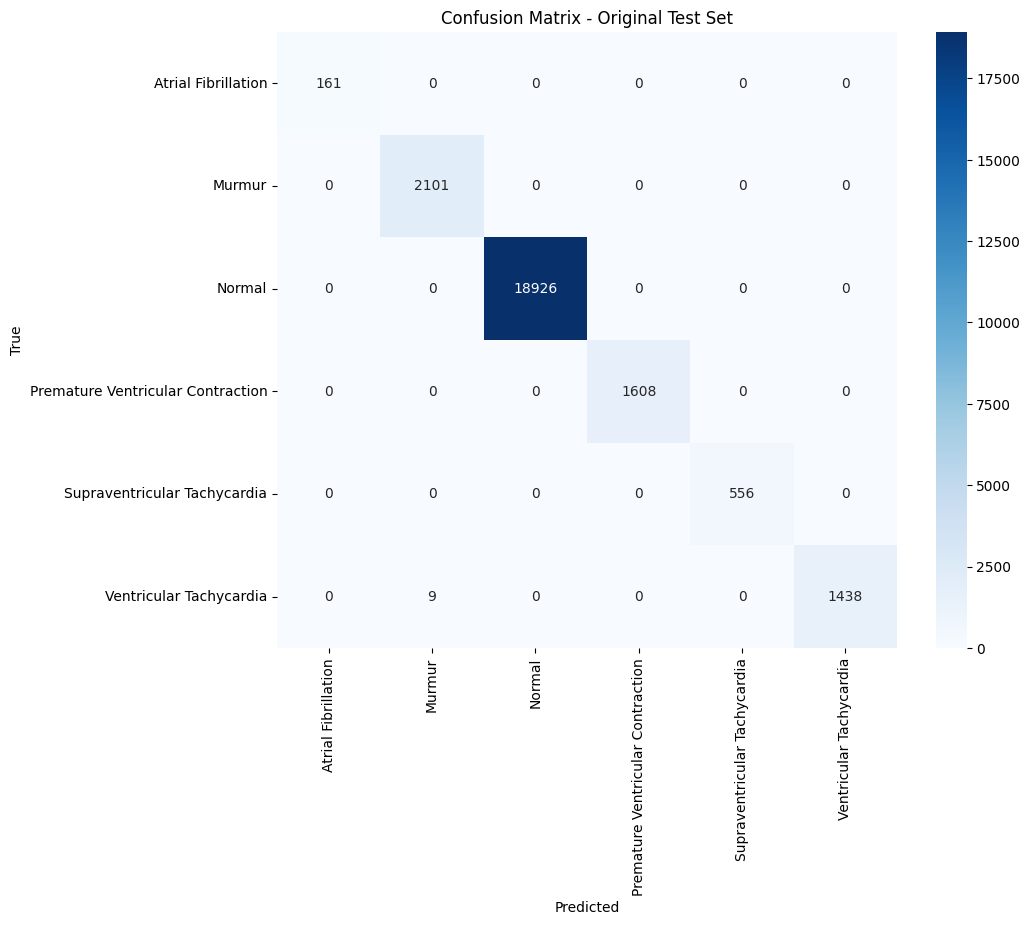

Classification Report on Original Test Set:
                                   precision    recall  f1-score   support

              Atrial Fibrillation       1.00      1.00      1.00       161
                           Murmur       1.00      1.00      1.00      2101
                           Normal       1.00      1.00      1.00     18926
Premature Ventricular Contraction       1.00      1.00      1.00      1608
     Supraventricular Tachycardia       1.00      1.00      1.00       556
          Ventricular Tachycardia       1.00      0.99      1.00      1447

                         accuracy                           1.00     24799
                        macro avg       1.00      1.00      1.00     24799
                     weighted avg       1.00      1.00      1.00     24799



In [18]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Define CNN Model (same as yours)
def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(160, 160, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(6, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_cnn_model()
model.summary()
# Remove the custom 3D wrapper completely!

train_generator = train_datagen.flow_from_directory(   # ← use this directly
    small_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    small_train_dir,
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='label',
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Your model is already correct for this:
model = create_cnn_model()   # input_shape=(160, 160, 3) is perfect
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_cnn_balanced_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

# Train the model
history = model.fit(
    train_generator,
    epochs=17,                    # Can go higher now that data is balanced
    validation_data=val_generator,
    callbacks=callbacks
)

# Save final model
model.save('/kaggle/working/cnn_ecg_balanced_final.h5')


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Load the best saved model
best_model = models.load_model('/kaggle/working/best_cnn_balanced_model.h5')

# Evaluate on original test set
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"\nFinal Test Accuracy (on original imbalanced test set): {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Predictions
y_pred = best_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
class_labels = list(test_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Original Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report (shows per-class precision/recall/F1)
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print("Classification Report on Original Test Set:")
print(report)

In [16]:
!python --version

Python 3.12.12


In [ ]:
!pip list --format=freeze>requirements.txt